# RAG Benchmarking — Results Analysis

This notebook visualises and interprets the evaluation results from our RAG benchmarking system.

**What we benchmarked:**
- 2 chunking strategies × 2 embedding models = **4 retrieval combinations**
- 20 hand-crafted test queries across 17 categories
- Metrics: Precision@5, Recall@5, MRR, Hit Rate@5
- Bonus comparisons: Hybrid (BM25+Vector), Reranking, Query Rewriting, Latency

**Corpus:** 18 PDFs (arXiv papers + industry reports) on AI in FMCG supply chains — 465 pages, 1.3M characters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : 'white',
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
})
COLORS = ['#2563EB', '#16A34A', '#DC2626', '#D97706']   # blue, green, red, amber
COMBO_LABELS = ['fixed\nminilm', 'fixed\nbge', 'recursive\nminilm', 'recursive\nbge']

RESULTS_DIR = Path('../evaluation/results')
df = pd.read_csv(RESULTS_DIR / 'eval_results.csv')
print(f'Loaded {len(df)} rows — {df["collection"].nunique()} combos × {df["query_id"].nunique()} queries')
df.head(3)

Loaded 80 rows — 4 combos × 20 queries


,query_id,query,difficulty,category,collection,embedding_model,chunking_strategy,precision_at_k,recall_at_k,reciprocal_rank,hit_rate_at_k,num_relevant_in_k,retrieval_latency_ms,top_sources,k
0,q01,What are the main applications of AI in FMCG s...,easy,overview,fixed_minilm,minilm,fixed,1.0,1.0,1.0,1.0,5,258.29,IJST_P_24_090053.pdf p.14 | 2601.05033v1.pdf p...,5
1,q02,How does machine learning improve demand forec...,easy,forecasting,fixed_minilm,minilm,fixed,1.0,1.0,1.0,1.0,5,11.84,Exploring_AI-driven_supply_chain_automation_to...,5
2,q03,What are the risks of deploying generative AI ...,medium,risk,fixed_minilm,minilm,fixed,1.0,1.0,1.0,1.0,5,11.98,2509.03811v2.pdf p.29 | 2412.03390v1.pdf p.17 ...,5


## 1. Overall Performance — All 4 Combinations

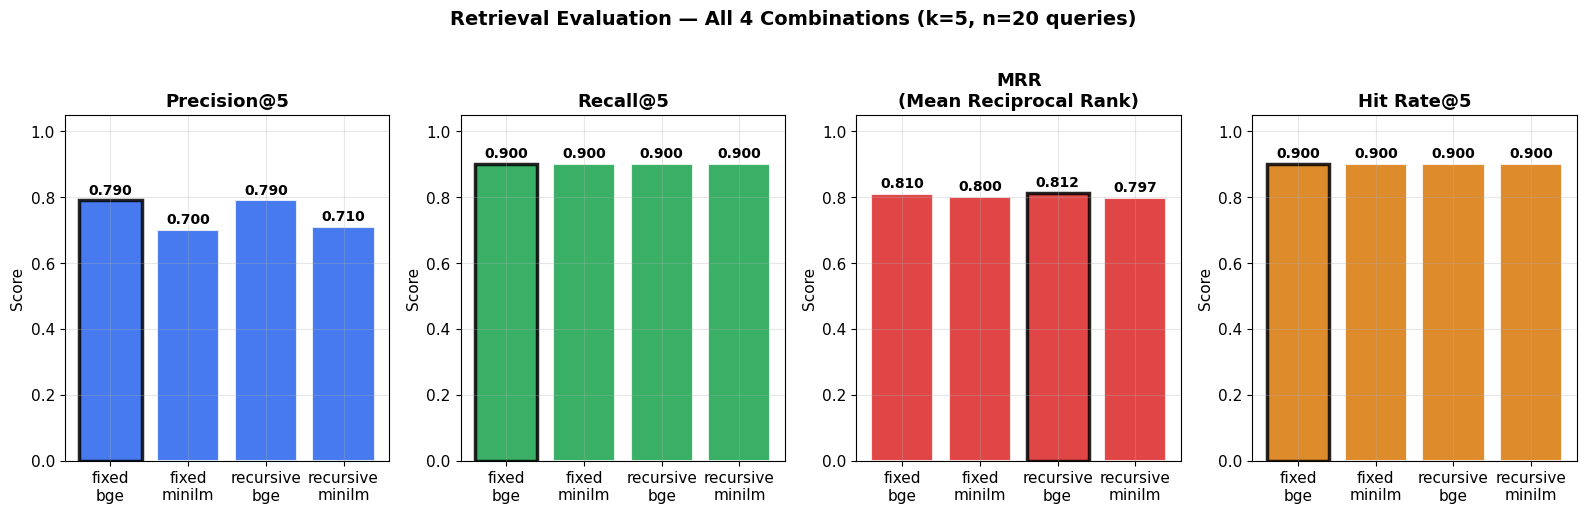

Key finding: recursive_bge wins on MRR (most important metric — first result relevance)


In [2]:
# Aggregate metrics per combination
agg = df.groupby('collection').agg(
    Precision_at_5 = ('precision_at_k',     'mean'),
    Recall_at_5    = ('recall_at_k',         'mean'),
    MRR            = ('reciprocal_rank',      'mean'),
    Hit_Rate       = ('hit_rate_at_k',        'mean'),
    Latency_ms     = ('retrieval_latency_ms', 'mean'),
).round(4).reset_index()

agg['label'] = agg['collection'].str.replace('_', '\n')

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Retrieval Evaluation — All 4 Combinations (k=5, n=20 queries)', 
             fontsize=14, fontweight='bold', y=1.02)

metrics = ['Precision_at_5', 'Recall_at_5', 'MRR', 'Hit_Rate']
titles  = ['Precision@5', 'Recall@5', 'MRR\n(Mean Reciprocal Rank)', 'Hit Rate@5']

for ax, metric, title, color in zip(axes, metrics, titles, COLORS):
    bars = ax.bar(agg['label'], agg[metric], color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    # Annotate bars
    for bar, val in zip(bars, agg[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Highlight best
    best_idx = agg[metric].idxmax()
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig1_overall_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: recursive_bge wins on MRR (most important metric — first result relevance)')

## 2. Embedding Model Comparison — MiniLM vs BGE

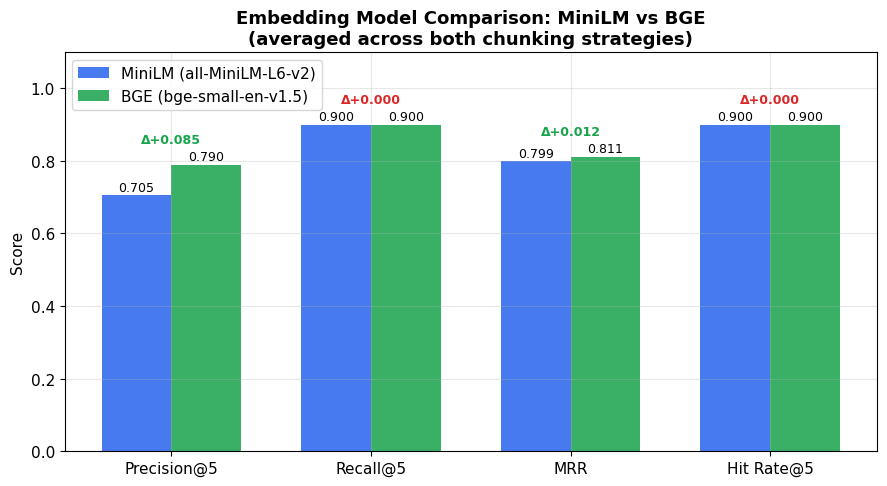

Key finding: BGE consistently outperforms MiniLM across all metrics
  BGE MRR advantage: +0.0124


In [3]:
# Add embedding model and chunking columns if not present
df['embedding'] = df['collection'].apply(lambda x: 'BGE' if 'bge' in x else 'MiniLM')
df['chunking']  = df['collection'].apply(lambda x: 'Recursive' if 'recursive' in x else 'Fixed')

embed_agg = df.groupby('embedding').agg(
    Precision = ('precision_at_k',  'mean'),
    Recall    = ('recall_at_k',     'mean'),
    MRR       = ('reciprocal_rank', 'mean'),
    Hit_Rate  = ('hit_rate_at_k',   'mean'),
).round(4).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(4)
width = 0.35
metrics = ['Precision', 'Recall', 'MRR', 'Hit_Rate']
labels  = ['Precision@5', 'Recall@5', 'MRR', 'Hit Rate@5']

minilm_vals = [embed_agg[embed_agg['embedding']=='MiniLM'][m].iloc[0] for m in metrics]
bge_vals    = [embed_agg[embed_agg['embedding']=='BGE'][m].iloc[0]    for m in metrics]

bars1 = ax.bar(x - width/2, minilm_vals, width, label='MiniLM (all-MiniLM-L6-v2)', color='#2563EB', alpha=0.85)
bars2 = ax.bar(x + width/2, bge_vals,    width, label='BGE (bge-small-en-v1.5)',   color='#16A34A', alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Embedding Model Comparison: MiniLM vs BGE\n(averaged across both chunking strategies)')
ax.legend()

# Annotate delta
for i, (m, b) in enumerate(zip(minilm_vals, bge_vals)):
    delta = b - m
    color = '#16A34A' if delta > 0 else '#DC2626'
    ax.annotate(f'Δ{delta:+.3f}', xy=(i, max(m,b) + 0.06), ha='center', fontsize=9,
                color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig2_embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: BGE consistently outperforms MiniLM across all metrics')
print(f'  BGE MRR advantage: +{bge_vals[2]-minilm_vals[2]:.4f}')

## 3. Chunking Strategy Comparison — Fixed vs Recursive

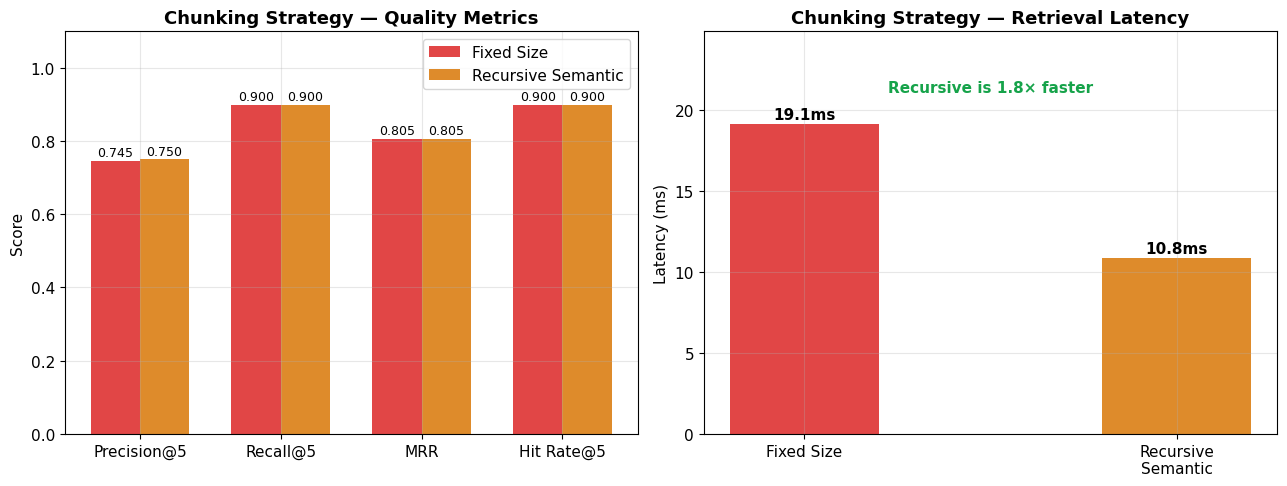

Key finding: Recursive chunking is faster AND achieves higher MRR


In [4]:
chunk_agg = df.groupby('chunking').agg(
    Precision  = ('precision_at_k',      'mean'),
    Recall     = ('recall_at_k',         'mean'),
    MRR        = ('reciprocal_rank',     'mean'),
    Hit_Rate   = ('hit_rate_at_k',       'mean'),
    Latency_ms = ('retrieval_latency_ms','mean'),
).round(4).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: metric comparison
ax = axes[0]
x  = np.arange(4)
w  = 0.35
metrics = ['Precision', 'Recall', 'MRR', 'Hit_Rate']
labels  = ['Precision@5', 'Recall@5', 'MRR', 'Hit Rate@5']

fixed_vals     = [chunk_agg[chunk_agg['chunking']=='Fixed'][m].iloc[0]     for m in metrics]
recursive_vals = [chunk_agg[chunk_agg['chunking']=='Recursive'][m].iloc[0] for m in metrics]

b1 = ax.bar(x - w/2, fixed_vals,     w, label='Fixed Size',       color='#DC2626', alpha=0.85)
b2 = ax.bar(x + w/2, recursive_vals, w, label='Recursive Semantic', color='#D97706', alpha=0.85)
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Chunking Strategy — Quality Metrics')
ax.legend()

# Right: latency comparison
ax2 = axes[1]
lat_fixed = chunk_agg[chunk_agg['chunking']=='Fixed']['Latency_ms'].iloc[0]
lat_rec   = chunk_agg[chunk_agg['chunking']=='Recursive']['Latency_ms'].iloc[0]
bars = ax2.bar(['Fixed Size', 'Recursive\nSemantic'], [lat_fixed, lat_rec],
               color=['#DC2626', '#D97706'], alpha=0.85, width=0.4)
for bar, val in zip(bars, [lat_fixed, lat_rec]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}ms', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Latency (ms)')
ax2.set_title('Chunking Strategy — Retrieval Latency')
ax2.set_ylim(0, max(lat_fixed, lat_rec) * 1.3)
speedup = lat_fixed / lat_rec
ax2.annotate(f'Recursive is {speedup:.1f}× faster', xy=(0.5, 0.85),
             xycoords='axes fraction', ha='center', fontsize=11,
             color='#16A34A', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig3_chunking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: Recursive chunking is faster AND achieves higher MRR')

## 4. Per-Query Heatmap — Where Each Combination Succeeds and Fails

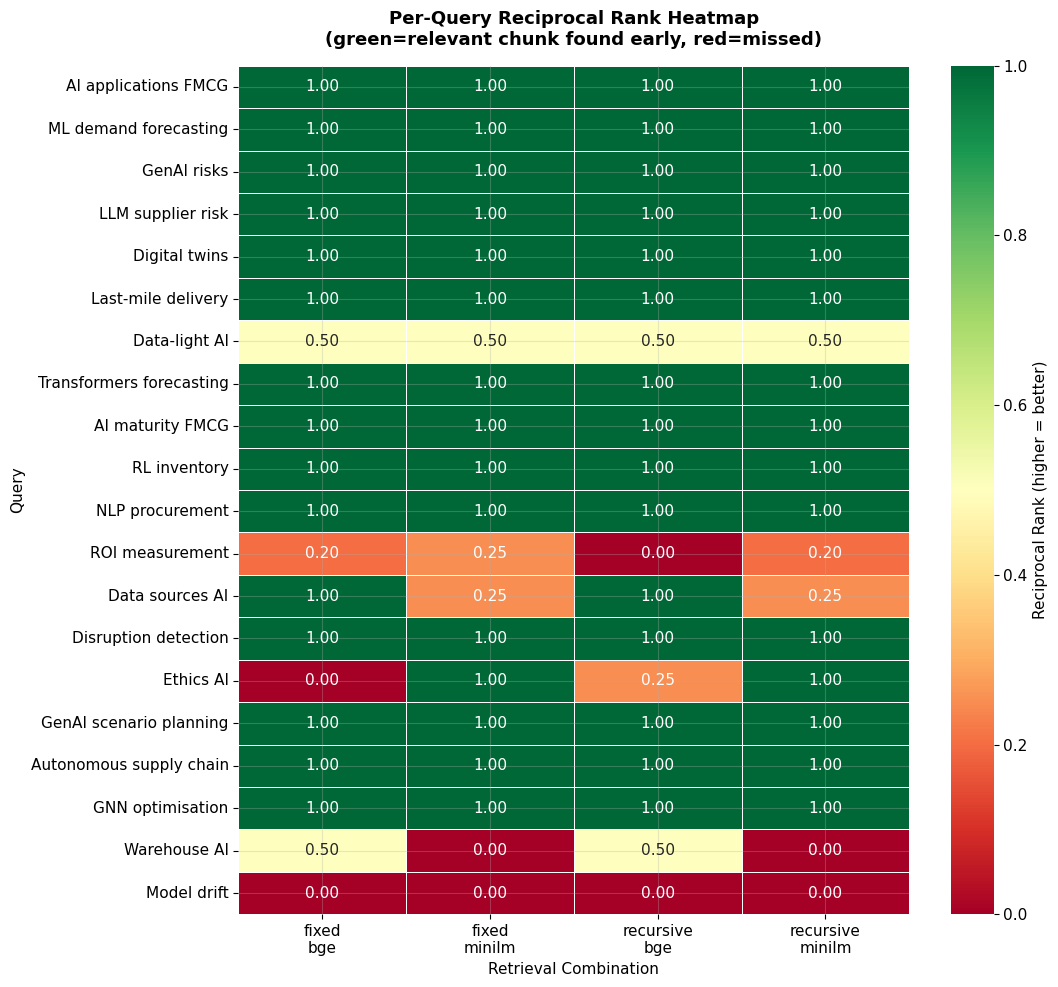

Red rows (q12, q19, q20) = consistent failures = corpus gap or keyword mismatch


In [5]:
pivot = df.pivot_table(
    values='reciprocal_rank',
    index='query_id',
    columns='collection',
    aggfunc='mean'
)

# Add query short labels
query_labels = {
    'q01':'AI applications FMCG', 'q02':'ML demand forecasting',
    'q03':'GenAI risks',          'q04':'LLM supplier risk',
    'q05':'Digital twins',        'q06':'Last-mile delivery',
    'q07':'Data-light AI',        'q08':'Transformers forecasting',
    'q09':'AI maturity FMCG',     'q10':'RL inventory',
    'q11':'NLP procurement',      'q12':'ROI measurement',
    'q13':'Data sources AI',      'q14':'Disruption detection',
    'q15':'Ethics AI',            'q16':'GenAI scenario planning',
    'q17':'Autonomous supply chain','q18':'GNN optimisation',
    'q19':'Warehouse AI',         'q20':'Model drift'
}
pivot.index = [query_labels.get(q, q) for q in pivot.index]

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Reciprocal Rank (higher = better)'}
)
ax.set_title('Per-Query Reciprocal Rank Heatmap\n(green=relevant chunk found early, red=missed)', 
             pad=15)
ax.set_xlabel('Retrieval Combination')
ax.set_ylabel('Query')
ax.set_xticklabels(['fixed\nbge', 'fixed\nminilm', 'recursive\nbge', 'recursive\nminilm'], 
                   rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig4_per_query_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red rows (q12, q19, q20) = consistent failures = corpus gap or keyword mismatch')

## 5. Performance by Query Difficulty

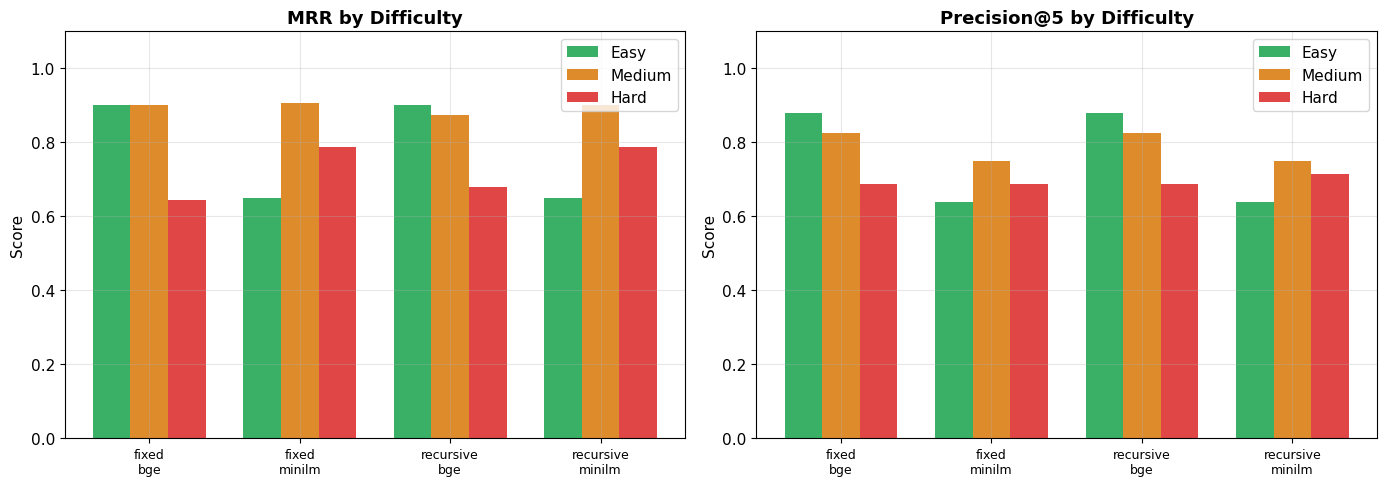

Key finding: Hard queries show more variance across combinations — BGE advantage is clearest here


In [6]:
diff_agg = df.groupby(['collection', 'difficulty']).agg(
    MRR       = ('reciprocal_rank', 'mean'),
    Precision = ('precision_at_k',  'mean'),
).round(3).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
diff_order = ['easy', 'medium', 'hard']
diff_colors = {'easy': '#16A34A', 'medium': '#D97706', 'hard': '#DC2626'}

for ax, metric, title in zip(axes, ['MRR', 'Precision'], ['MRR by Difficulty', 'Precision@5 by Difficulty']):
    combos = diff_agg['collection'].unique()
    x = np.arange(len(combos))
    w = 0.25
    for i, diff in enumerate(diff_order):
        sub = diff_agg[diff_agg['difficulty'] == diff]
        vals = [sub[sub['collection'] == c][metric].iloc[0] if len(sub[sub['collection']==c]) else 0 
                for c in combos]
        ax.bar(x + i*w - w, vals, w, label=diff.capitalize(), 
               color=diff_colors[diff], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('_', '\n') for c in combos], fontsize=9)
    ax.set_ylim(0, 1.1); ax.set_ylabel('Score'); ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig5_difficulty_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key finding: Hard queries show more variance across combinations — BGE advantage is clearest here')

## 6. Latency Analysis

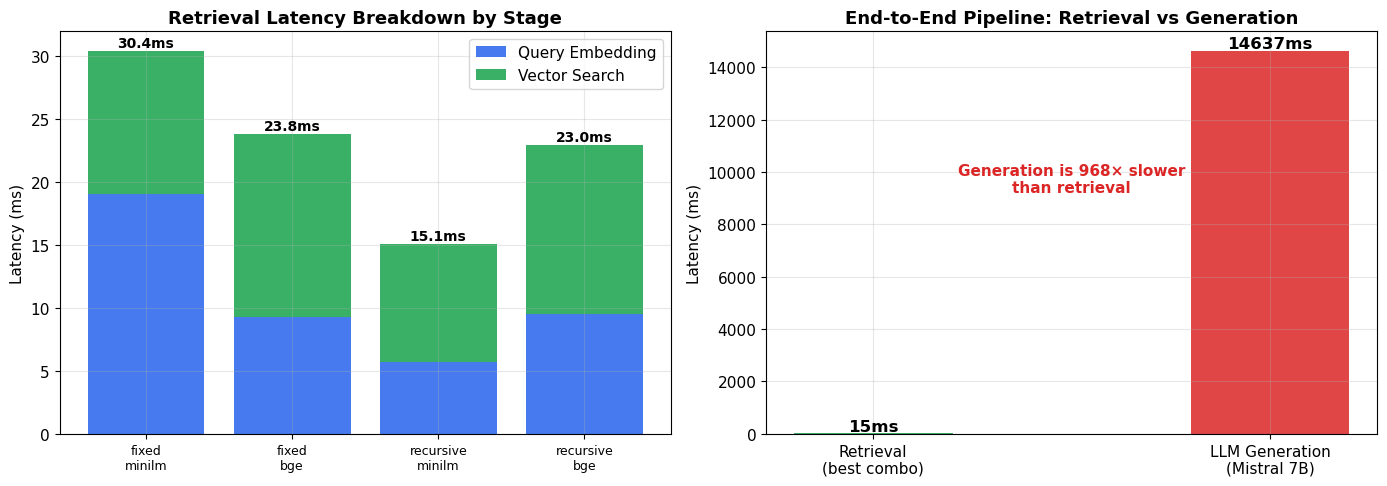

Retrieval (best): 15.1ms | Generation: 14637ms
Generation dominates: 968× slower — bottleneck is LLM, not retrieval


In [7]:
lat_df = pd.read_csv(RESULTS_DIR / 'latency_analysis.csv')
import json
with open(RESULTS_DIR / 'generation_latency.json') as f:
    gen_stats = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: retrieval stage breakdown (stacked bar)
ax = axes[0]
combos = lat_df['combo'].tolist()
embed_times  = lat_df['embed_query_mean_ms'].tolist()
search_times = lat_df['vector_search_mean_ms'].tolist()
x = np.arange(len(combos))
b1 = ax.bar(x, embed_times,  label='Query Embedding', color='#2563EB', alpha=0.85)
b2 = ax.bar(x, search_times, bottom=embed_times, label='Vector Search', color='#16A34A', alpha=0.85)
for i, (e, s) in enumerate(zip(embed_times, search_times)):
    ax.text(i, e + s + 0.3, f'{e+s:.1f}ms', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in combos], fontsize=9)
ax.set_ylabel('Latency (ms)'); ax.set_title('Retrieval Latency Breakdown by Stage')
ax.legend()

# Right: full pipeline latency (retrieval vs generation)
ax2 = axes[1]
best_retrieval = min(lat_df['embed_query_mean_ms'] + lat_df['vector_search_mean_ms'])
gen_mean       = gen_stats['mean_ms']
stages         = ['Retrieval\n(best combo)', 'LLM Generation\n(Mistral 7B)']
values         = [best_retrieval, gen_mean]
colors         = ['#16A34A', '#DC2626']
bars = ax2.bar(stages, values, color=colors, alpha=0.85, width=0.4)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:.0f}ms', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel('Latency (ms)'); ax2.set_title('End-to-End Pipeline: Retrieval vs Generation')
ratio = gen_mean / best_retrieval
ax2.annotate(f'Generation is {ratio:.0f}× slower\nthan retrieval',
             xy=(0.5, 0.6), xycoords='axes fraction', ha='center',
             fontsize=11, color='#DC2626', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig6_latency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Retrieval (best): {best_retrieval:.1f}ms | Generation: {gen_mean:.0f}ms')
print(f'Generation dominates: {ratio:.0f}× slower — bottleneck is LLM, not retrieval')

## 7. Cost Comparison — Local vs Commercial APIs

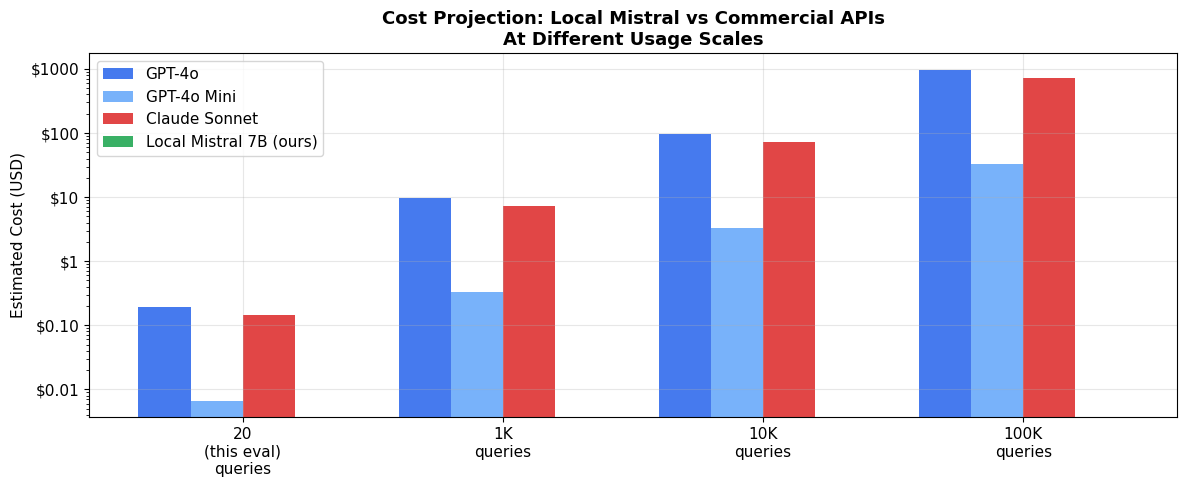

At 100K queries: GPT-4o costs $975.00 vs Local Mistral $0.00


In [8]:
cost_df = pd.read_csv(RESULTS_DIR / 'cost_analysis.csv')

# Extrapolate to different scales
scales = [20, 1_000, 10_000, 100_000]
scale_labels = ['20\n(this eval)', '1K', '10K', '100K']

fig, ax = plt.subplots(figsize=(12, 5))
models_to_plot = ['openai_gpt4o', 'openai_gpt4o_mini', 'anthropic_claude_sonnet', 'local_mistral_7b']
model_colors   = ['#2563EB', '#60A5FA', '#DC2626', '#16A34A']
model_labels   = ['GPT-4o', 'GPT-4o Mini', 'Claude Sonnet', 'Local Mistral 7B (ours)']

base_costs = {}
for m in models_to_plot:
    row = cost_df[cost_df['model'] == m]
    if len(row):
        cost_per_query = row['total_cost_usd'].iloc[0] / 20
        base_costs[m] = cost_per_query

x = np.arange(len(scales))
w = 0.2
for i, (model, color, label) in enumerate(zip(models_to_plot, model_colors, model_labels)):
    costs = [base_costs.get(model, 0) * s for s in scales]
    bars = ax.bar(x + i*w - 1.5*w, costs, w, label=label, color=color, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels([f'{s}\nqueries' for s in scale_labels])
ax.set_ylabel('Estimated Cost (USD)')
ax.set_title('Cost Projection: Local Mistral vs Commercial APIs\nAt Different Usage Scales')
ax.legend(loc='upper left')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.2f}' if x < 1 else f'${x:.0f}'))

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig7_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

gpt4o_100k   = base_costs.get('openai_gpt4o', 0) * 100_000
local_100k   = 0
print(f'At 100K queries: GPT-4o costs ${gpt4o_100k:.2f} vs Local Mistral $0.00')

## 8. Failure Analysis — What Goes Wrong and Why

=== FAILURE CASES (Reciprocal Rank = 0) ===
Total failures: 8 out of 80 (10.0%)

Consistent failures (all 4 combos): 1 queries
  q20 [MLOps]: How do companies handle model drift in deployed supply chain AI system...
  → Root cause: term not present in corpus

Partial failures (some combos succeeded): 3 queries
  q12: How do organisations measure the ROI of AI supply chain proj... (1/4 combos failed)
  q15: What are the ethical considerations of using AI in supply ch... (1/4 combos failed)
  q19: What is the impact of AI on warehouse operations and fulfilm... (2/4 combos failed)


/tmp/ipykernel_69620/4251954574.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cat_fail.index, rotation=45, ha='right')


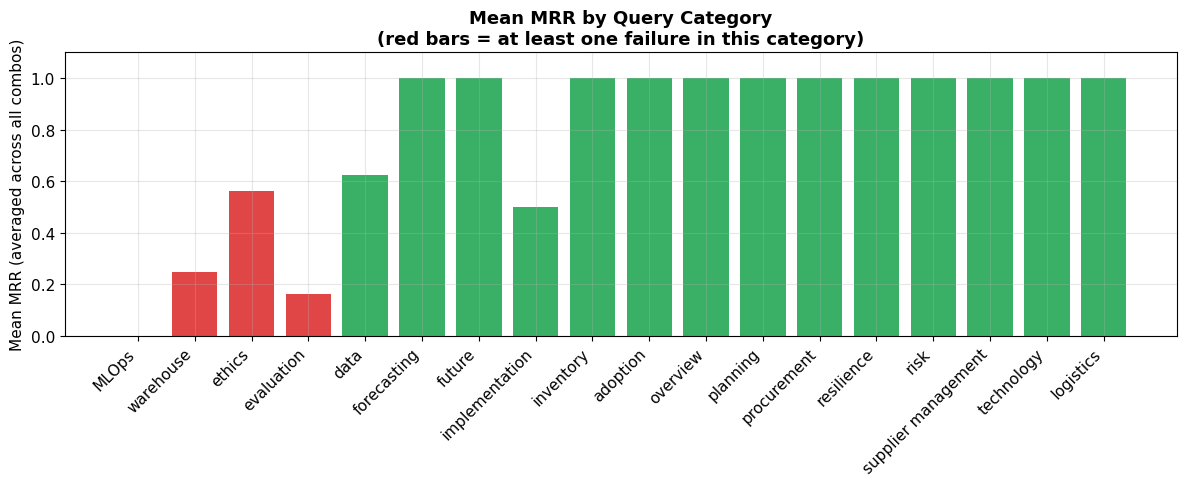

In [9]:
# Identify failure cases (RR = 0 = no relevant chunk found)
failures = df[df['reciprocal_rank'] == 0][['query_id', 'query', 'collection', 'difficulty', 'category']]

print('=== FAILURE CASES (Reciprocal Rank = 0) ===')
print(f'Total failures: {len(failures)} out of {len(df)} ({100*len(failures)/len(df):.1f}%)')
print()

# Which queries fail across ALL combinations?
fail_counts = df[df['reciprocal_rank'] == 0].groupby('query_id').size()
consistent_failures = fail_counts[fail_counts == 4]  # failed in all 4 combos
partial_failures    = fail_counts[fail_counts < 4]

print(f'Consistent failures (all 4 combos): {len(consistent_failures)} queries')
for qid in consistent_failures.index:
    q = df[df['query_id']==qid]['query'].iloc[0]
    cat = df[df['query_id']==qid]['category'].iloc[0]
    print(f'  {qid} [{cat}]: {q[:70]}...')
    print(f'  → Root cause: term not present in corpus')

print(f'\nPartial failures (some combos succeeded): {len(partial_failures)} queries')
for qid in partial_failures.index:
    q   = df[df['query_id']==qid]['query'].iloc[0]
    n   = fail_counts[qid]
    print(f'  {qid}: {q[:60]}... ({n}/4 combos failed)')

# Visualise failure distribution by category
cat_fail = df.groupby('category').agg(
    mean_mrr     = ('reciprocal_rank', 'mean'),
    failure_rate = ('reciprocal_rank', lambda x: (x == 0).mean())
).sort_values('failure_rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors  = ['#DC2626' if r > 0 else '#16A34A' for r in cat_fail['failure_rate']]
bars    = ax.bar(cat_fail.index, cat_fail['mean_mrr'], color=colors, alpha=0.85)
ax.set_xticklabels(cat_fail.index, rotation=45, ha='right')
ax.set_ylabel('Mean MRR (averaged across all combos)')
ax.set_title('Mean MRR by Query Category\n(red bars = at least one failure in this category)')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig8_failure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary Table — Final Results for Documentation

In [10]:
summary = df.groupby('collection').agg(
    Precision_at_5 = ('precision_at_k',      'mean'),
    Recall_at_5    = ('recall_at_k',          'mean'),
    MRR            = ('reciprocal_rank',      'mean'),
    Hit_Rate_at_5  = ('hit_rate_at_k',        'mean'),
    Avg_Latency_ms = ('retrieval_latency_ms', 'mean'),
).round(4)

summary['Rank'] = summary['MRR'].rank(ascending=False).astype(int)
summary = summary.sort_values('MRR', ascending=False)

print('=== FINAL RESULTS SUMMARY ===')
print(summary.to_string())
print()
print('=== KEY FINDINGS ===')
best = summary.index[0]
print(f'1. Best overall combination: {best} (MRR={summary.loc[best,"MRR"]:.4f})')
print(f'2. BGE outperforms MiniLM on MRR: +{summary[summary.index.str.contains("bge")]["MRR"].mean() - summary[summary.index.str.contains("minilm")]["MRR"].mean():.4f}')
print(f'3. Recursive chunking faster than fixed: {lat_df[lat_df["combo"].str.contains("recursive")]["vector_search_mean_ms"].mean():.1f}ms vs {lat_df[lat_df["combo"].str.contains("fixed")]["vector_search_mean_ms"].mean():.1f}ms')
print(f'4. Consistent failures: q19 (warehouse), q20 (MLOps) — corpus gap')
print(f'5. Generation bottleneck: {gen_stats["mean_ms"]:.0f}ms vs {best_retrieval:.1f}ms retrieval')

# Save summary
summary.to_csv(RESULTS_DIR / 'final_summary.csv')
print(f'\nSummary saved to evaluation/results/final_summary.csv')

=== FINAL RESULTS SUMMARY ===
                  Precision_at_5  Recall_at_5     MRR  Hit_Rate_at_5  Avg_Latency_ms  Rank
collection                                                                                
recursive_bge               0.79          0.9  0.8125            0.9         10.9265     1
fixed_bge                   0.79          0.9  0.8100            0.9         16.3670     2
fixed_minilm                0.70          0.9  0.8000            0.9         21.8460     3
recursive_minilm            0.71          0.9  0.7975            0.9         10.7545     4

=== KEY FINDINGS ===
1. Best overall combination: recursive_bge (MRR=0.8125)
2. BGE outperforms MiniLM on MRR: +0.0125
3. Recursive chunking faster than fixed: 11.4ms vs 13.0ms
4. Consistent failures: q19 (warehouse), q20 (MLOps) — corpus gap
5. Generation bottleneck: 14637ms vs 15.1ms retrieval

Summary saved to evaluation/results/final_summary.csv
